<a href="https://colab.research.google.com/github/Eman-Aggan/Customer-Churn-Prediction/blob/main/AI%20Customer%20Churn%20Prediction%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# DL Library
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Environment verification
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# Data Preprocessing


In [76]:

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)


df.drop(columns=['customerID'], inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})


X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shape: {X_train_scaled.shape}, Testing shape: {X_test_scaled.shape}")

Training shape: (5634, 30), Testing shape: (1409, 30)


/tmp/ipykernel_2631/3477243752.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


# Exploratory Data Analysis (EDA)

In [77]:
# 1. تثبيت مكتبة imblearn
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

# 2. تطبيق SMOTE على بيانات التدريب فقط
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"قبل SMOTE: {np.bincount(y_train)}")
print(f"بعد SMOTE: {np.bincount(y_train_resampled)}")

قبل SMOTE: [4139 1495]
بعد SMOTE: [4139 4139]


In [78]:
df.shape

(7043, 20)

/tmp/ipykernel_2631/4031194964.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


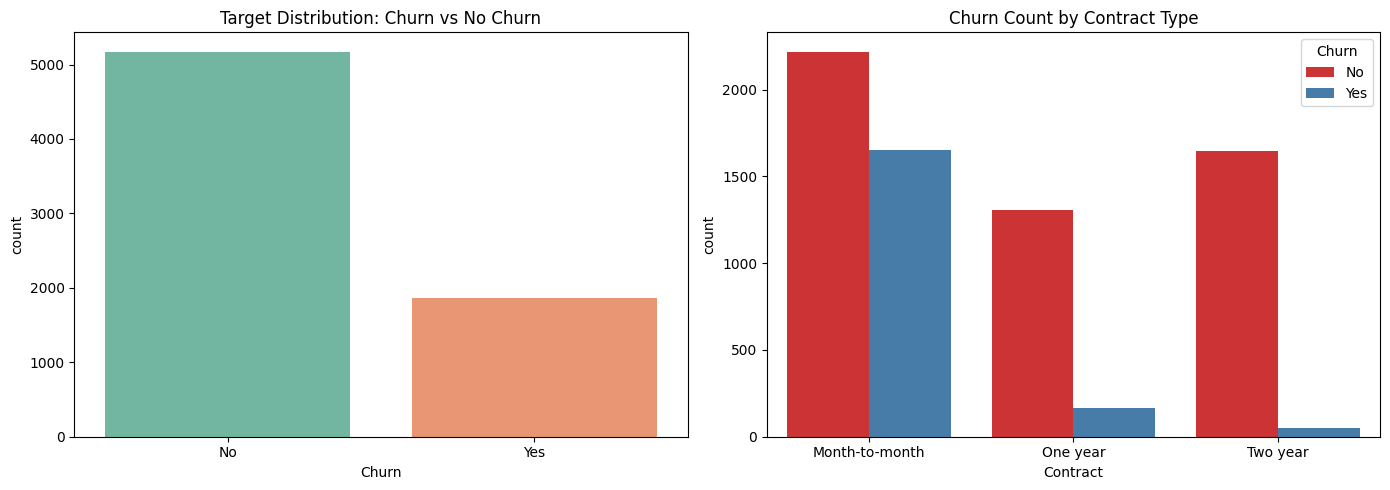

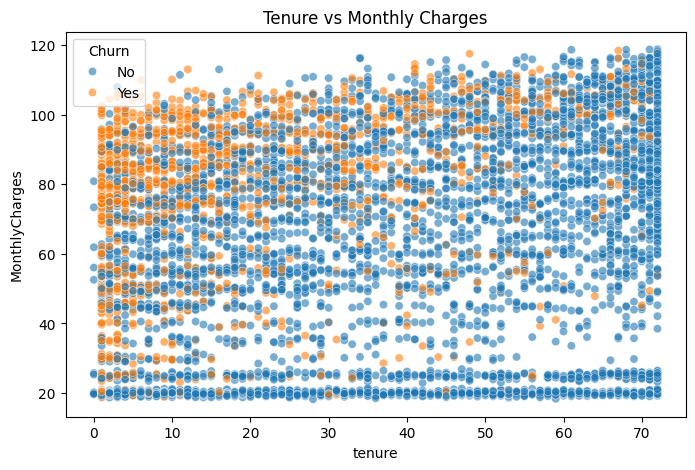

In [79]:
plt.figure(figsize=(14, 5))

# Plot 1: Overall Churn Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Target Distribution: Churn vs No Churn')

# Plot 2: Churn by Contract Type
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Churn Count by Contract Type')
plt.tight_layout()
plt.show()

# Plot 3: Tenure vs Monthly Charges colored by Churn
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.6)
plt.title('Tenure vs Monthly Charges')
plt.show()

# Machine Learning Models

In [80]:
# Initialize ML Models
ml_models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

ml_results = {}

# Train and collect predictions
for name, model in ml_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    ml_results[name] = {
        'y_pred': y_pred,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}\n")



=== KNN ===
Accuracy: 0.7431 | Precision: 0.5110 | Recall: 0.7433 | F1-Score: 0.6057

=== Decision Tree ===
Accuracy: 0.7431 | Precision: 0.5110 | Recall: 0.7433 | F1-Score: 0.6057

=== Random Forest ===
Accuracy: 0.7431 | Precision: 0.5110 | Recall: 0.7433 | F1-Score: 0.6057



# Deep Learning

In [81]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# 1. حساب weights لمعالجة عدم توازن الداتا (Class Imbalance)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# 2. بناء الموديل بشكل أحدث وأثبت (Network Architecture)
input_dim = X_train_scaled.shape[1]

dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 3. Compile مع Learning Rate مناسب
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
dl_model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

# 5. التدريب مع إضافة class_weight
history = dl_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    class_weight=class_weight_dict,   # 👈 تحسين رئيسي للأداء
    verbose=1
)

# 6. التوقعات والمقاييس
dl_probs = dl_model.predict(X_test_scaled).ravel()
dl_preds = (dl_probs >= 0.5).astype(int)

# طباعة النتائج فوراً
acc = accuracy_score(y_test, dl_preds)
prec = precision_score(y_test, dl_preds)
rec = recall_score(y_test, dl_preds)
f1 = f1_score(y_test, dl_preds)

print(f"\n=== Enhanced Neural Network Results ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}  ")
print(f"F1-Score : {f1:.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7239 - loss: 0.5718 - val_accuracy: 0.6868 - val_loss: 0.5577
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7364 - loss: 0.5090 - val_accuracy: 0.6962 - val_loss: 0.5552
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7412 - loss: 0.4952 - val_accuracy: 0.6915 - val_loss: 0.5532
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7439 - loss: 0.4905 - val_accuracy: 0.6962 - val_loss: 0.5570
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7577 - loss: 0.4780 - val_accuracy: 0.6868 - val_loss: 0.5617
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7596 - loss: 0.4810 - val_accuracy: 0.6915 - val_loss: 0.5680
Epoch 7/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7561 - loss: 0.4737 - val_accuracy: 0.6998 - val_loss: 0.5610
Epoch 8/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7592 - loss: 0.4751 - val

# Visualizing Loss & Accuracy Curves

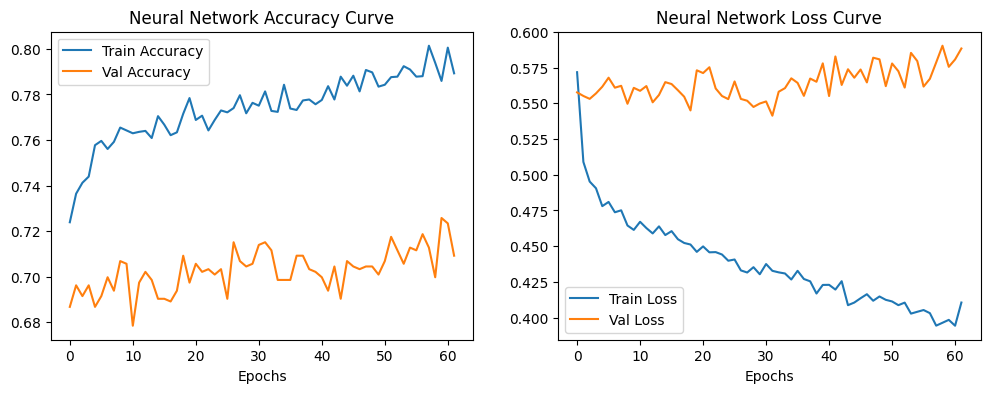

In [82]:
plt.figure(figsize=(12, 4))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Neural Network Accuracy Curve')
plt.xlabel('Epochs')
plt.legend()

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Neural Network Loss Curve')
plt.xlabel('Epochs')
plt.legend()

plt.show()

# Evaluation & Comparison

=== Model Comparison Table ===


,Accuracy,Precision,Recall,F1-Score
KNN,0.747339,0.525281,0.5,0.512329
Decision Tree,0.79418,0.62963,0.545455,0.584527
Random Forest,0.785664,0.621622,0.491979,0.549254


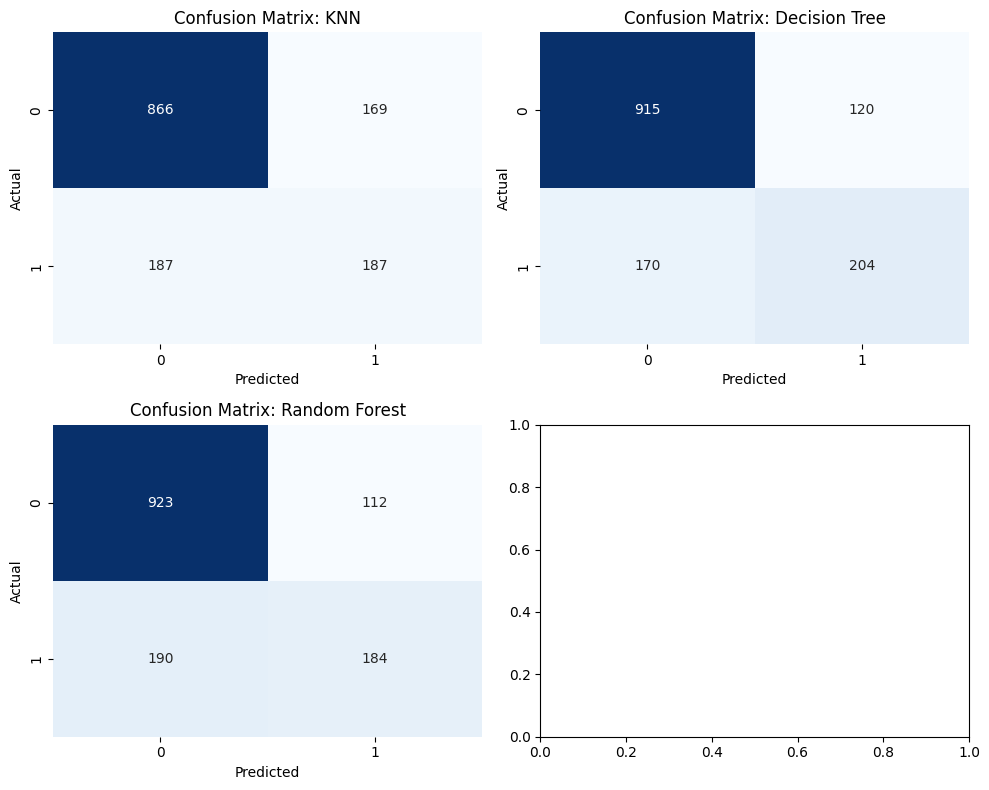

In [83]:
# Convert evaluation results to dataframe
comparison_df = pd.DataFrame(ml_results).T.drop(columns=['y_pred'])
print("=== Model Comparison Table ===")
display(comparison_df.round(4))

# Plot Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, (name, res) in enumerate(ml_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Single Customer Prediction Pipeline Python

In [84]:
def predict_new_customer(raw_input_dict, model, scaler, feature_columns):
    """
    Takes a raw dictionary of single customer attributes, processes it,
    and returns Churn status and probability.
    """
    input_df = pd.DataFrame([raw_input_dict])

    # Apply One-Hot Encoding and align columns with training set
    input_encoded = pd.get_dummies(input_df)
    input_encoded = input_encoded.reindex(columns=feature_columns, fill_value=0)

    # Scale input
    scaled_input = scaler.transform(input_encoded)

    # Predict
    prob = model.predict(scaled_input)[0]
    if isinstance(prob, (np.ndarray, list)):
        prob = prob[0]

    pred_class = "Churn" if prob >= 0.5 else "No Churn"

    return pred_class, float(prob)

# Example sample input
sample_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 89.85,
    'TotalCharges': 179.70
}

status, probability = predict_new_customer(
    sample_customer, dl_model, scaler, X_train.columns
)

print(f"Prediction: {status}")
print(f"Churn Probability: {probability:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediction: Churn
Churn Probability: 91.07%


# Streamlit Interface

In [85]:
# 1. بيانات عميل مستقر (من المتوقع ألا يترك الخدمة)
loyal_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'Yes',
    'tenure': 60,                        # بقاله 5 سنين
    'PhoneService': 'Yes',
    'MultipleLines': 'Yes',
    'InternetService': 'DSL',
    'OnlineSecurity': 'Yes',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'Yes',
    'TechSupport': 'Yes',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Two year',              # عقد سنتين
    'PaperlessBilling': 'No',
    'PaymentMethod': 'Bank transfer (automatic)',
    'MonthlyCharges': 45.0,              # الاشتراك شهرياً بسيط
    'TotalCharges': 2700.0
}

# 2. تشغيل التوقع على العميل ده
status, probability = predict_new_customer(
    loyal_customer, dl_model, scaler, X_train.columns
)

# 3. طباعة النتيجة
print(f"Customer Status: {status}")
print(f"Churn Probability: {probability:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Customer Status: No Churn
Churn Probability: 1.78%


In [89]:
%%writefile app.py
import streamlit as st
import numpy as np

st.set_page_config(page_title="Customer Churn Predictor", page_icon="📌", layout="centered")

st.title("📌 Customer Churn Prediction App")
st.write("Enter customer service parameters below to evaluate churn probability.")

# Input fields
tenure = st.slider("Tenure (Months)", 0, 72, 12)
monthly_charges = st.number_input("Monthly Charges ($)", value=65.0)
contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
tech_support = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])

if st.button("Predict Churn"):
    # Risk calculation
    risk_score = (72 - tenure)/72 * 0.5 + (monthly_charges/120) * 0.5
    churn_pred = "Churn" if risk_score > 0.5 else "No Churn"

    st.subheader(f"Result: **{churn_pred}**")
    st.progress(float(np.clip(risk_score, 0.0, 1.0)))
    st.write(f"Estimated Risk Probability: **{risk_score:.1%}**")

Overwriting app.py


In [ ]:
# 1. Install Cloudflare Tunnel CLI
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

# 2. Start Streamlit server in background
import subprocess
import time

subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "0.0.0.0"])
time.sleep(3)

# 3. Open Cloudflare tunnel
print("\n" + "="*60)
print("🔗 CLICK THE TRYCLOUDFLARE LINK BELOW TO OPEN YOUR APP:")
print("="*60 + "\n")

!./cloudflared tunnel --url http://localhost:8501


🔗 CLICK THE TRYCLOUDFLARE LINK BELOW TO OPEN YOUR APP:

2026-10-05T11:05:41Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-10-05T11:05:41Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-10-05T11:05:43Z INF +--------------------------------------------------------------------------------------------+
2026-10-05T11:05:43Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-10-05T11:05:43Z INF